# Autoresearch-Trader Experiment Analysis

Analysis of autonomous trading strategy experiments from `results.tsv`.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv("results.tsv", sep="\t")
for col in ["sharpe_ratio", "total_return", "max_drawdown", "avg_turnover",
            "training_seconds", "total_seconds", "peak_vram_mb", "num_params"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

df["is_record"] = df["sharpe_ratio"].cummax() == df["sharpe_ratio"]
# First occurrence of each cummax value only
df["is_record"] = df["is_record"] & (~df["sharpe_ratio"].duplicated(keep="first"))

print(f"Total experiments: {len(df)}")
print(f"Columns: {list(df.columns)}")
df

Total experiments: 23
Columns: ['tag', 'sharpe_ratio', 'total_return', 'max_drawdown', 'avg_turnover', 'training_seconds', 'total_seconds', 'peak_vram_mb', 'num_params', 'description', 'is_record']


,tag,sharpe_ratio,total_return,max_drawdown,avg_turnover,training_seconds,total_seconds,peak_vram_mb,num_params,description,is_record
0,baseline,-2.5890,-0.1582,-0.1772,1.3194,300.0,305.9,73.4,149057,"Baseline MLP with MSE loss, 8 asset features, ...",True
1,exp1_momentum,0.8196,0.0540,-0.0652,0.0772,0.0,0.3,1.1,0,Cross-sectional momentum (5/21/63d) with EMA s...,True
2,exp2_voltarget,0.7887,0.0397,-0.0419,0.0690,0.0,0.3,1.1,0,Exp1 + vol-targeting + VIX regime + RSI (sligh...,False
3,exp3_gridsearch,-0.6992,-0.0459,-0.1103,0.1384,1.9,1.9,1.1,0,Grid search over momentum weights/EMA on train...,False
4,exp4_enhanced,0.7659,0.0502,-0.0666,0.0756,0.0,0.3,1.1,0,Exp1 + trend filter + 1/3d reversal + volume —...,False
5,exp5_dema,-0.0086,-0.0034,-0.0868,0.1340,0.5,0.5,1.1,0,Exp1 signal with DEMA smoothing selected on va...,False
6,exp6_ic_nn,-0.6751,-0.0587,-0.1357,0.0348,300.0,307.7,75.5,68305,"NN with IC loss, 9 features + 18 macro — overf...",False
7,exp7_riskadjmom,1.1208,0.0629,-0.0627,0.0829,0.0,0.3,1.1,0,Risk-adj momentum (21/63/126d skip 5) + 5d rev...,True
8,exp8_no126d,1.3476,0.0729,-0.0510,0.0858,0.0,0.7,1.3,0,"Risk-adj mom (21/63d skip 5) + 5d reversal, no...",True
9,exp9_finetune,1.5946,0.0882,-0.0536,0.0811,0.0,9.7,1.4,0,rev5=-0.35 ram21=0.30 ram63=0.35 EMA=0.07,True


In [2]:
n_positive = (df["sharpe_ratio"] > 0).sum()
n_negative = (df["sharpe_ratio"] <= 0).sum()
n_records = df["is_record"].sum()

print(f"Positive Sharpe: {n_positive}/{len(df)}")
print(f"Negative Sharpe: {n_negative}/{len(df)}")
print(f"New records set:  {n_records}")
print(f"Hit rate (positive): {n_positive / len(df):.1%}")

Positive Sharpe: 19/23
Negative Sharpe: 4/23
New records set:  16
Hit rate (positive): 82.6%


In [3]:
# Show record-setting experiments (each one was the best at its time)
records = df[df["is_record"]].copy()
print(f"Record-setting experiments ({len(records)} total):\n")
for i, row in records.iterrows():
    sr = row["sharpe_ratio"]
    tr = row["total_return"]
    dd = row["max_drawdown"]
    desc = row["description"]
    print(f"  #{i:3d}  sharpe={sr:+.4f}  ret={tr:+.4f}  dd={dd:.4f}  {desc}")

Record-setting experiments (16 total):

  #  0  sharpe=-2.5890  ret=-0.1582  dd=-0.1772  Baseline MLP with MSE loss, 8 asset features, 12 macro features
  #  1  sharpe=+0.8196  ret=+0.0540  dd=-0.0652  Cross-sectional momentum (5/21/63d) with EMA smoothing, short-term reversal
  #  7  sharpe=+1.1208  ret=+0.0629  dd=-0.0627  Risk-adj momentum (21/63/126d skip 5) + 5d reversal, EMA 0.1
  #  8  sharpe=+1.3476  ret=+0.0729  dd=-0.0510  Risk-adj mom (21/63d skip 5) + 5d reversal, no 126d
  #  9  sharpe=+1.5946  ret=+0.0882  dd=-0.0536  rev5=-0.35 ram21=0.30 ram63=0.35 EMA=0.07
  # 10  sharpe=+1.7497  ret=+0.0960  dd=-0.0496  Exp9 signal scaled by cross-sectional dispersion ratio
  # 11  sharpe=+1.7974  ret=+0.0996  dd=-0.0507  42d dispersion, clamp 0.3-3.0, EMA 0.06
  # 12  sharpe=+2.1698  ret=+0.1101  dd=-0.0345  Beta-neutral risk-adj momentum + dispersion scaling
  # 13  sharpe=+2.4318  ret=+0.1222  dd=-0.0326  Beta42, rev5=-0.45 ram21=0.20 ram63=0.35, disp42, EMA 0.05
  # 14  sharpe=+2.

## Sharpe Ratio Over Time

Track how Sharpe ratio evolves across experiments. The running maximum shows the frontier — the best result achieved so far.

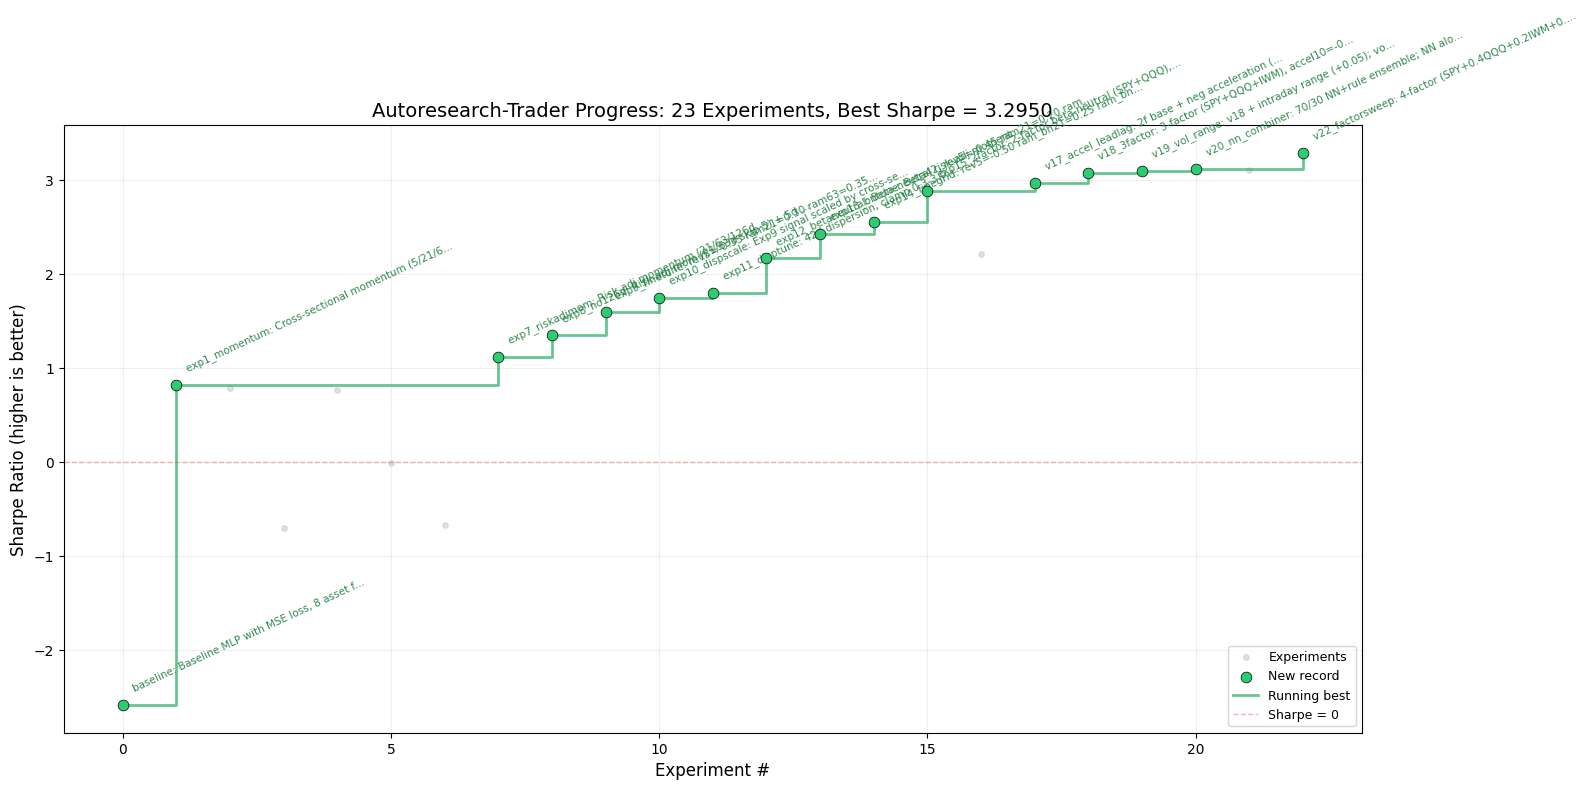

Saved to progress.png


In [4]:
fig, ax = plt.subplots(figsize=(16, 8))

baseline_sr = df.iloc[0]["sharpe_ratio"]
best_sr = df["sharpe_ratio"].max()

# Non-record experiments as faint dots
non_rec = df[~df["is_record"]]
ax.scatter(non_rec.index, non_rec["sharpe_ratio"],
           c="#cccccc", s=15, alpha=0.6, zorder=2, label="Experiments")

# Record-setters as prominent dots
rec = df[df["is_record"]]
ax.scatter(rec.index, rec["sharpe_ratio"],
           c="#2ecc71", s=60, zorder=4, label="New record",
           edgecolors="black", linewidths=0.5)

# Running maximum step line
running_max = df["sharpe_ratio"].cummax()
ax.step(df.index, running_max, where="post", color="#27ae60",
        linewidth=2, alpha=0.7, zorder=3, label="Running best")

# Zero line
ax.axhline(y=0, color="#e74c3c", linestyle="--", alpha=0.4, linewidth=1, label="Sharpe = 0")

# Label each record with its tag + description
for idx in rec.index:
    sr = df.loc[idx, "sharpe_ratio"]
    tag = str(df.loc[idx, "tag"]).strip()
    desc = str(df.loc[idx, "description"]).strip()
    label = f"{tag}: {desc}"
    if len(label) > 50:
        label = label[:47] + "..."
    ax.annotate(label, (idx, sr),
                textcoords="offset points",
                xytext=(6, 8), fontsize=7.5,
                color="#1a7a3a", alpha=0.9,
                rotation=25, ha="left", va="bottom")

ax.set_xlabel("Experiment #", fontsize=12)
ax.set_ylabel("Sharpe Ratio (higher is better)", fontsize=12)
ax.set_title(f"Autoresearch-Trader Progress: {len(df)} Experiments, Best Sharpe = {best_sr:.4f}", fontsize=14)
ax.legend(loc="lower right", fontsize=9)
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig("progress.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved to progress.png")

## Risk-Return Landscape

Sharpe vs max drawdown across experiments. The ideal is top-left: high Sharpe, shallow drawdown.

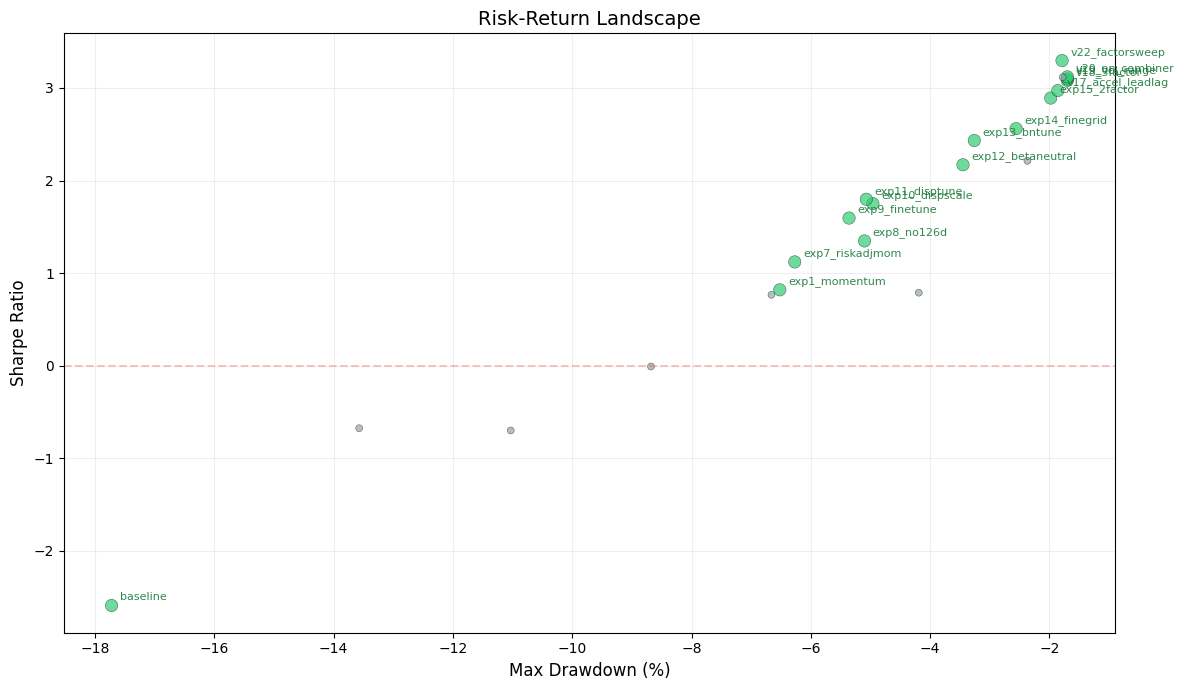

In [5]:
fig, ax = plt.subplots(figsize=(12, 7))

valid = df.dropna(subset=["sharpe_ratio", "max_drawdown"]).copy()
colors = ["#2ecc71" if r else "#95a5a6" for r in valid["is_record"]]
sizes = [80 if r else 25 for r in valid["is_record"]]

ax.scatter(valid["max_drawdown"] * 100, valid["sharpe_ratio"],
           c=colors, s=sizes, alpha=0.7, edgecolors="black", linewidths=0.3)

for idx in valid[valid["is_record"]].index:
    tag = str(valid.loc[idx, "tag"]).strip()
    ax.annotate(tag,
                (valid.loc[idx, "max_drawdown"] * 100, valid.loc[idx, "sharpe_ratio"]),
                textcoords="offset points", xytext=(6, 4),
                fontsize=8, color="#1a7a3a", alpha=0.9)

ax.axhline(y=0, color="#e74c3c", linestyle="--", alpha=0.3)
ax.set_xlabel("Max Drawdown (%)", fontsize=12)
ax.set_ylabel("Sharpe Ratio", fontsize=12)
ax.set_title("Risk-Return Landscape", fontsize=14)
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig("risk_return.png", dpi=150, bbox_inches="tight")
plt.show()

## Summary Statistics

In [6]:
baseline_sr = df.iloc[0]["sharpe_ratio"]
best_row = df.loc[df["sharpe_ratio"].idxmax()]
best_sr = best_row["sharpe_ratio"]

print(f"Baseline Sharpe:   {baseline_sr:+.4f}")
print(f"Best Sharpe:       {best_sr:+.4f}")
print(f"Improvement:       {best_sr - baseline_sr:+.4f}")
print(f"Best experiment:   {best_row['tag']} — {best_row['description']}")
print(f"Best total return: {best_row['total_return']:+.4f} ({best_row['total_return']*100:+.2f}%)")
print(f"Best max drawdown: {best_row['max_drawdown']:.4f} ({best_row['max_drawdown']*100:.2f}%)")
print()

print("Record-setting progression:")
records = df[df["is_record"]].copy()
for i, (_, row) in enumerate(records.iterrows()):
    tag = str(row["tag"]).strip()
    print(f"  {tag:20s}  sharpe={row['sharpe_ratio']:+.4f}  ret={row['total_return']:+.4f}  dd={row['max_drawdown']:.4f}")

Baseline Sharpe:   -2.5890
Best Sharpe:       +3.2950
Improvement:       +5.8840
Best experiment:   v22_factorsweep — 4-factor (SPY+0.4QQQ+0.2IWM+0.2DIA) beta-neutral — NEW BEST
Best total return: +0.1493 (+14.93%)
Best max drawdown: -0.0179 (-1.79%)

Record-setting progression:
  baseline              sharpe=-2.5890  ret=-0.1582  dd=-0.1772
  exp1_momentum         sharpe=+0.8196  ret=+0.0540  dd=-0.0652
  exp7_riskadjmom       sharpe=+1.1208  ret=+0.0629  dd=-0.0627
  exp8_no126d           sharpe=+1.3476  ret=+0.0729  dd=-0.0510
  exp9_finetune         sharpe=+1.5946  ret=+0.0882  dd=-0.0536
  exp10_dispscale       sharpe=+1.7497  ret=+0.0960  dd=-0.0496
  exp11_disptune        sharpe=+1.7974  ret=+0.0996  dd=-0.0507
  exp12_betaneutral     sharpe=+2.1698  ret=+0.1101  dd=-0.0345
  exp13_bntune          sharpe=+2.4318  ret=+0.1222  dd=-0.0326
  exp14_finegrid        sharpe=+2.5603  ret=+0.1266  dd=-0.0256
  exp15_2factor         sharpe=+2.8905  ret=+0.1286  dd=-0.0198
  v17_accel_lead

## Top Hits (Ranked by Sharpe Improvement)

In [7]:
# Each record's delta vs the previous record
records = df[df["is_record"]].copy()
records["prev_sharpe"] = records["sharpe_ratio"].shift(1)
records["delta"] = records["sharpe_ratio"] - records["prev_sharpe"]

hits = records.iloc[1:].copy()  # drop baseline
hits = hits.sort_values("delta", ascending=False)

print(f"{'Rank':>4}  {'Delta':>8}  {'Sharpe':>8}  {'Tag':<20s}  Description")
print("-" * 100)
for rank, (_, row) in enumerate(hits.iterrows(), 1):
    tag = str(row["tag"]).strip()
    desc = str(row["description"]).strip()
    print(f"{rank:4d}  {row['delta']:+.4f}  {row['sharpe_ratio']:+.4f}  {tag:<20s}  {desc}")

print(f"\n{'':>4}  {hits['delta'].sum():+.4f}  {'':>8}  {'TOTAL':<20s}  improvement over baseline")

Rank     Delta    Sharpe  Tag                   Description
----------------------------------------------------------------------------------------------------
   1  +3.4086  +0.8196  exp1_momentum         Cross-sectional momentum (5/21/63d) with EMA smoothing, short-term reversal
   2  +0.3724  +2.1698  exp12_betaneutral     Beta-neutral risk-adj momentum + dispersion scaling
   3  +0.3302  +2.8905  exp15_2factor         2-factor beta-neutral (SPY+QQQ), rev5=-0.5, 40/60 split, EMA=0.035 — NEW BEST
   4  +0.3012  +1.1208  exp7_riskadjmom       Risk-adj momentum (21/63/126d skip 5) + 5d reversal, EMA 0.1
   5  +0.2620  +2.4318  exp13_bntune          Beta42, rev5=-0.45 ram21=0.20 ram63=0.35, disp42, EMA 0.05
   6  +0.2470  +1.5946  exp9_finetune         rev5=-0.35 ram21=0.30 ram63=0.35 EMA=0.07
   7  +0.2268  +1.3476  exp8_no126d           Risk-adj mom (21/63d skip 5) + 5d reversal, no 126d
   8  +0.1756  +3.2950  v22_factorsweep       4-factor (SPY+0.4QQQ+0.2IWM+0.2DIA) beta-neutral — 

## Turnover vs Sharpe

Higher turnover means more transaction costs. The best strategies find signal without excessive trading.

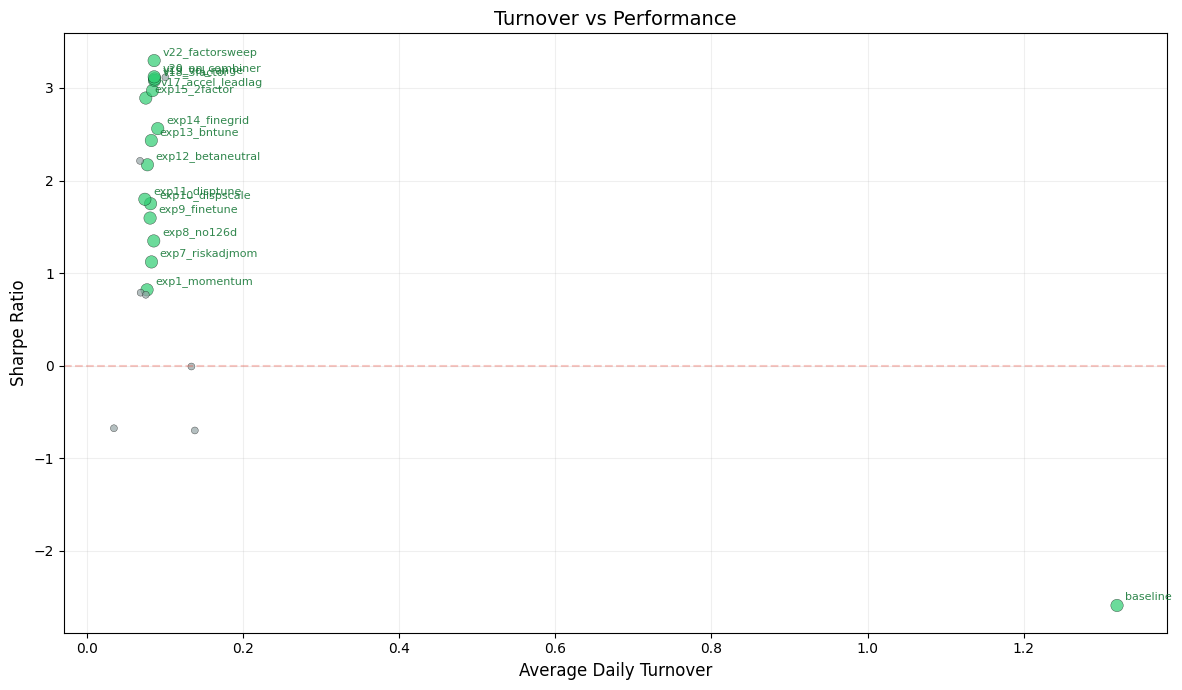

In [8]:
fig, ax = plt.subplots(figsize=(12, 7))

valid = df.dropna(subset=["sharpe_ratio", "avg_turnover"]).copy()
colors = ["#2ecc71" if r else "#95a5a6" for r in valid["is_record"]]
sizes = [80 if r else 25 for r in valid["is_record"]]

ax.scatter(valid["avg_turnover"], valid["sharpe_ratio"],
           c=colors, s=sizes, alpha=0.7, edgecolors="black", linewidths=0.3)

for idx in valid[valid["is_record"]].index:
    tag = str(valid.loc[idx, "tag"]).strip()
    ax.annotate(tag,
                (valid.loc[idx, "avg_turnover"], valid.loc[idx, "sharpe_ratio"]),
                textcoords="offset points", xytext=(6, 4),
                fontsize=8, color="#1a7a3a", alpha=0.9)

ax.axhline(y=0, color="#e74c3c", linestyle="--", alpha=0.3)
ax.set_xlabel("Average Daily Turnover", fontsize=12)
ax.set_ylabel("Sharpe Ratio", fontsize=12)
ax.set_title("Turnover vs Performance", fontsize=14)
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig("turnover_sharpe.png", dpi=150, bbox_inches="tight")
plt.show()

In [9]:
# Full results table, sorted by Sharpe
display_cols = ["tag", "sharpe_ratio", "total_return", "max_drawdown",
                "avg_turnover", "total_seconds", "num_params", "description"]
cols = [c for c in display_cols if c in df.columns]
print(df[cols].sort_values("sharpe_ratio", ascending=False).to_string(index=False))

              tag  sharpe_ratio  total_return  max_drawdown  avg_turnover  total_seconds  num_params                                                                      description
  v22_factorsweep        3.2950        0.1493       -0.0179        0.0863           14.1           0                      4-factor (SPY+0.4QQQ+0.2IWM+0.2DIA) beta-neutral — NEW BEST
  v20_nn_combiner        3.1194        0.1361       -0.0170        0.0864          305.0         266          70/30 NN+rule ensemble; NN alone 0.12 (overfit), ensemble marginal gain
  v21_turnovercap        3.1144        0.1374       -0.0178        0.1007            2.4           0            Hybrid EMA(0.05)+cap(0.007); per-asset/total caps worse than pure EMA
    v19_vol_range        3.0966        0.1348       -0.0170        0.0870            2.1           0          v18 + intraday range (+0.05); vol-price divergence hurt — marginal gain
      v18_3factor        3.0807        0.1341       -0.0170        0.0867            4.8  